# OCR_receipts 성능 지표 분석

이 노트북은 OCR 파이프라인의 **핵심 성능 지표**를 분석하고 시각화합니다.

## 3.4 핵심 지표 (학술적 기준)

| 지표 | 설명 |
|------|------|
| **Character Accuracy** | 문자 단위 정확도 |
| **Word Accuracy** | 단어 단위 정확도 |
| **Processing Time** | 이미지 1장 처리 시간 |
| **Extraction Success Rate** | 핵심 필드(가맹점/날짜/합계) 추출 성공률 |

In [1]:
import sys
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트 추가
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

DATA = ROOT / "data"
JSON_DIR = DATA / "json"
LINES_DIR = DATA / "outputs" / "lines"
PARSED_DIR = DATA / "outputs" / "parsed"
RAW_IMAGES = DATA / "raw_images" / "img"
GT_PATH = DATA / "ground_truth.json"  # 정답 라벨 (선택)

print(f"ROOT: {ROOT}")
print(f"LINES_DIR: {LINES_DIR.exists()}")
print(f"PARSED_DIR: {PARSED_DIR.exists()}")
# 처리 시간 측정 시 NumPy 1.26.4 필요. 커널이 venv인지 확인용:
try:
    import numpy as np
    print(f"커널 Python: {sys.executable}")
    print(f"NumPy 버전: {np.__version__}  ← 1.26.x 여야 처리 시간 실제 측정 가능")
except Exception as e:
    print("NumPy:", e)

ROOT: d:\VScode\smartBudget\smartbudget\AI-service\OCR_receipts
LINES_DIR: True
PARSED_DIR: True
커널 Python: c:\Python310\python.exe
NumPy 버전: 1.26.4  ← 1.26.x 여야 처리 시간 실제 측정 가능


---
## 1. 데이터 로드

In [2]:
def load_lines_json(stem: str) -> dict | None:
    p = LINES_DIR / f"{stem}.lines.json"
    if p.exists():
        return json.loads(p.read_text(encoding="utf-8"))
    return None

def load_parsed_json(stem: str) -> dict | None:
    p = PARSED_DIR / f"{stem}.receipt.json"
    if p.exists():
        return json.loads(p.read_text(encoding="utf-8"))
    return None

def load_raw_json(stem: str) -> dict | None:
    p = JSON_DIR / f"{stem}.json"
    if p.exists():
        return json.loads(p.read_text(encoding="utf-8"))
    return None

# 출력 파일에서 stem 목록 추출
stems = []
if LINES_DIR.exists():
    for f in LINES_DIR.glob("*.lines.json"):
        stems.append(f.stem.replace(".lines", ""))
stems = list(dict.fromkeys(stems))

print(f"분석 대상 파일 수: {len(stems)}")
print(f"Stems: {stems}")

분석 대상 파일 수: 8
Stems: ['KakaoTalk_20260204_114853043_01', 'KakaoTalk_20260204_114853043_02', 'KakaoTalk_20260204_115306376', 'KakaoTalk_20260205_161316079_02', 'KakaoTalk_20260205_161316079_05', 'KakaoTalk_20260205_161316079_06', 'KakaoTalk_20260205_161316079_08', 'KakaoTalk_20260205_161316079_09']


In [3]:
# 데이터 로드
lines_data, parsed_data, raw_data = {}, {}, {}
for f in (LINES_DIR.glob("*.lines.json") if LINES_DIR.exists() else []):
    stem = f.stem.replace(".lines", "")
    lines_data[stem] = json.loads(f.read_text(encoding="utf-8"))
    pp = PARSED_DIR / f"{stem}.receipt.json"
    if pp.exists():
        parsed_data[stem] = json.loads(pp.read_text(encoding="utf-8"))
    rp = JSON_DIR / f"{stem}.json"
    if rp.exists():
        raw_data[stem] = json.loads(rp.read_text(encoding="utf-8"))

print(f"Lines: {len(lines_data)}, Parsed: {len(parsed_data)}, Raw: {len(raw_data)}")

Lines: 8, Parsed: 8, Raw: 8


---
## OCR 탐지 시각화 (x,y 좌표 기반)

PaddleOCR이 탐지한 텍스트 영역의 **x,y 좌표(박스)** 를 이미지 위에 그려 시각화합니다.
- **빨간색 박스**: 각 텍스트 블록의 4 꼭짓점 좌표 (`box`)
- 아래 셀에서 `IMAGE_PATH` 또는 `stem`으로 분석할 이미지를 지정하세요.

In [4]:
import cv2
import numpy as np

def draw_ocr_boxes_on_image(image_path: Path | str, raw_json: dict | None = None, 
                             box_color=(255, 0, 0), thickness=2, show_text=True, 
                             font_scale=0.5, text_color=(0, 255, 0)):
    """
    OCR 탐지 결과(x,y 좌표)를 이미지 위에 박스로 시각화.
    - image_path: 이미지 파일 경로
    - raw_json: None이면 OCR 실행. 이미 있으면 그대로 사용.
    - box_color: BGR (기본 빨간색)
    """
    img_path = Path(image_path)
    img = cv2.imread(str(img_path))
    if img is None:
        return None, None
    
    # OCR 실행 또는 기존 raw_json 사용
    if raw_json is None:
        try:
            from src.parse.run_ocr_to_json import ocr_image_to_raw_json
            raw_json = ocr_image_to_raw_json(img_path)
        except Exception as e:
            print("OCR 실행 실패:", e)
            return img, None
    
    # 복사본에 그리기
    vis = img.copy()
    items = raw_json.get("items", [])
    
    for item in items:
        box = item.get("box")
        text = item.get("text", "")
        score = item.get("score", 0)
        
        if not box or len(box) < 4:
            continue
        
        # 4 꼭짓점 좌표 -> numpy array (정수)
        pts = np.array([[int(p[0]), int(p[1])] for p in box], dtype=np.int32)
        pts = pts.reshape((-1, 1, 2))
        
        # 빨간색 박스 그리기
        cv2.polylines(vis, [pts], isClosed=True, color=box_color, thickness=thickness)
        
        # 텍스트 라벨 (선택)
        if show_text and text:
            x1 = int(min(p[0] for p in box))
            y1 = int(min(p[1] for p in box))
            label = f"{text[:20]}{'...' if len(text) > 20 else ''}"
            cv2.putText(vis, label, (x1, max(0, y1 - 4)), 
                       cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, 1)
    
    return vis, raw_json

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

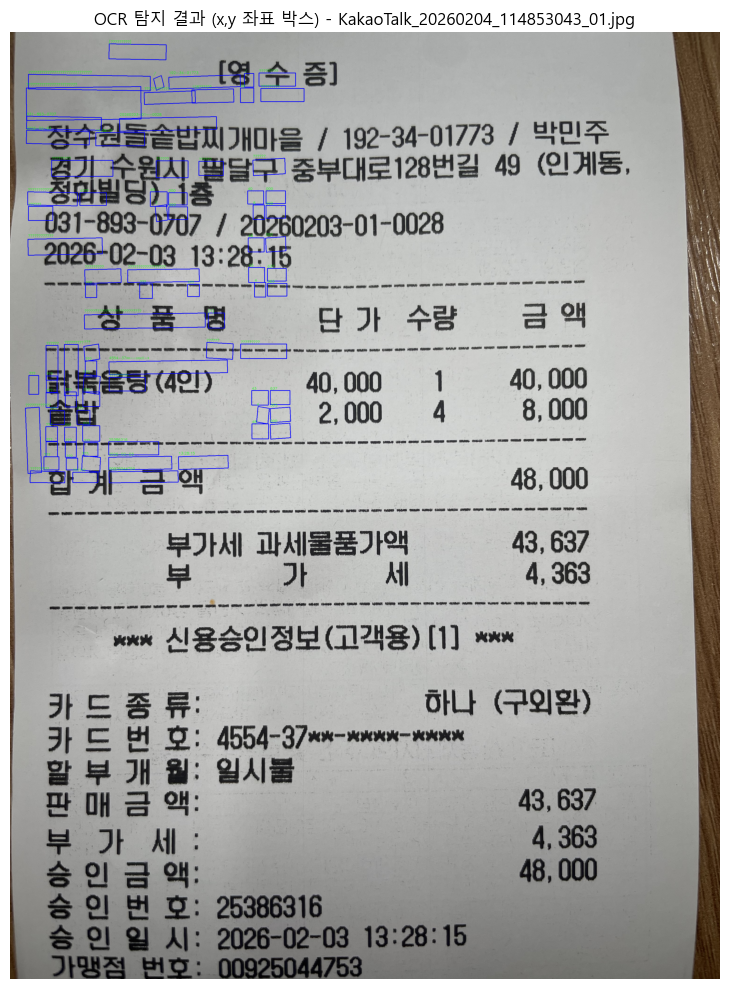

탐지된 텍스트 블록 수: 82


In [5]:
# === 이미지 경로 지정 ===
# 방법 1: data/raw_images/img 폴더의 stem (파일명에서 확장자 제외)
stem = stems[0] if stems else None  # 첫 번째 이미지 (또는 "receiptImage202601231042" 등)

# 방법 2: 직접 경로 지정 (내가 올린 사진 등)
IMAGE_PATH = None  # 예: Path("D:/my_receipt.jpg")

# stem이 있으면 data/raw_images/img에서 해당 이미지 찾기
if stem and IMAGE_PATH is None and RAW_IMAGES.exists():
    for f in list(RAW_IMAGES.glob("*.png")) + list(RAW_IMAGES.glob("*.jpg")) + list(RAW_IMAGES.glob("*.jpeg")):
        if f.stem == stem or stem in f.stem:
            IMAGE_PATH = f
            break

# fallback: raw_images/img의 첫 이미지
if IMAGE_PATH is None and RAW_IMAGES.exists():
    imgs = list(RAW_IMAGES.glob("*.png")) + list(RAW_IMAGES.glob("*.jpg")) + list(RAW_IMAGES.glob("*.jpeg"))
    if imgs:
        IMAGE_PATH = imgs[0]

# 실행
if IMAGE_PATH and Path(IMAGE_PATH).exists():
    raw_js = None
    if stem and "raw_data" in dir() and stem in raw_data:
        raw_js = raw_data[stem]
    vis_img, ocr_result = draw_ocr_boxes_on_image(IMAGE_PATH, raw_json=raw_js)
    if vis_img is not None:
        # BGR -> RGB (matplotlib 표시용)
        vis_rgb = cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 10))
        plt.imshow(vis_rgb)
        plt.axis("off")
        plt.title(f"OCR 탐지 결과 (x,y 좌표 박스) - {Path(IMAGE_PATH).name}")
        plt.tight_layout()
        plt.show()
        if ocr_result:
            print(f"탐지된 텍스트 블록 수: {len(ocr_result.get('items', []))}")
else:
    print("이미지 없음. IMAGE_PATH 또는 stem을 지정하고 data/raw_images/img에 이미지를 넣으세요.")

**직접 올린 이미지 분석:**  
`IMAGE_PATH = Path("내이미지경로.jpg")` 로 지정하고, `stem = None` 으로 두면 해당 이미지에 OCR을 실행한 뒤 박스를 그립니다.

---
## 2. 지표 1: Character Accuracy / Word Accuracy

- Ground Truth가 있으면 CER/Character Accuracy, WER/Word Accuracy 계산
- 없으면 OCR confidence score를 **정확도 proxy**로 사용

In [6]:
def char_accuracy_from_gt(pred: str, gt: str) -> float:
    """문자 단위 정확도 (일치 문자 수 / GT 문자 수)"""
    if not gt:
        return 1.0
    pred_chars = list(pred)
    gt_chars = list(gt)
    matches = sum(1 for a, b in zip(pred_chars, gt_chars) if a == b)
    return matches / len(gt_chars)

def word_accuracy_from_gt(pred_words: list[str], gt_words: list[str]) -> float:
    """단어 단위 정확도"""
    if not gt_words:
        return 1.0
    matches = sum(1 for a, b in zip(pred_words, gt_words) if a == b)
    return matches / len(gt_words)

def collect_ocr_text_and_scores(lines_dict: dict) -> tuple[list[str], list[float]]:
    """lines_json에서 전체 텍스트와 score 수집"""
    texts, scores = [], []
    for ln in lines_dict.get("lines", []):
        for t in ln.get("tokens", []):
            txt = t.get("text", "").strip()
            sc = float(t.get("score", 0))
            if txt:
                texts.append(txt)
                scores.append(sc)
    return texts, scores

# Confidence 기반 proxy (GT 없을 때)
char_acc_proxy = []  # 토큰별 평균 score = 문자 정확도 proxy
per_image = []
for stem, ld in lines_data.items():
    texts, scores = collect_ocr_text_and_scores(ld)
    if scores:
        avg = sum(scores) / len(scores)
        char_acc_proxy.append(avg)
        per_image.append({"stem": stem, "char_acc_proxy": avg, "token_count": len(scores)})

overall_char_proxy = sum(char_acc_proxy) / len(char_acc_proxy) if char_acc_proxy else 0
print(f"[Confidence Proxy] 평균 Character Accuracy (토큰 score): {overall_char_proxy:.2%}")
for x in per_image[:5]:
    print(f"  {x['stem'][:20]}: {x['char_acc_proxy']:.2%}")

[Confidence Proxy] 평균 Character Accuracy (토큰 score): 95.87%
  KakaoTalk_20260204_1: 98.34%
  KakaoTalk_20260204_1: 97.90%
  KakaoTalk_20260204_1: 94.23%
  KakaoTalk_20260205_1: 98.43%
  KakaoTalk_20260205_1: 91.18%


In [7]:
# Ground Truth 로드 (있을 경우)
# 형식: {"image_stem": {"merchant": "...", "date": "...", "total": 12345, "full_text": "..."}}
gt = {}
if GT_PATH.exists():
    gt = json.loads(GT_PATH.read_text(encoding="utf-8"))
    print(f"Ground Truth 로드: {len(gt)}건")
else:
    print("Ground Truth 없음. data/ground_truth.json 생성 시 Character/Word Accuracy 정확 계산 가능.")

Ground Truth 로드: 3건


---
## 3. 지표 2: Processing Time (처리 시간)

이미지 1장당 OCR 파이프라인 처리 시간 측정

In [8]:
def measure_processing_time(n_trials: int = 2):
    """raw_images/img 또는 data 내 이미지로 처리 시간 측정"""
    from src.parse.pipeline import process_ocr_lines_parsed

    img_dir = RAW_IMAGES if RAW_IMAGES.exists() else DATA
    img_paths = list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.jpeg"))
    if not img_paths:
        return None

    times = []
    for p in img_paths[:5]:
        img_bytes = p.read_bytes()
        t0 = time.perf_counter()
        for _ in range(n_trials):
            process_ocr_lines_parsed(img_bytes, p.name)
        elapsed = (time.perf_counter() - t0) / n_trials
        times.append({"image": p.name, "time_sec": elapsed})
    return times

# pipeline import 시 numpy/cv2/paddle 호환 오류 나면 시뮬레이션 값 사용
_measure_error = None
try:
    proc_times = measure_processing_time()
except (ImportError, RuntimeError) as e:
    proc_times = None
    _measure_error = str(e)

if proc_times:
    avg_time = sum(t["time_sec"] for t in proc_times) / len(proc_times)
    print(f"평균 처리 시간: {avg_time:.2f}초/이미지")
    print(proc_times)
else:
    if _measure_error:
        if "numpy" in _measure_error.lower() or "ABI" in _measure_error or "multiarray" in _measure_error:
            print("⚠ 원인: NumPy/OpenCV 호환 오류 (이 커널은 NumPy 2.x 사용 중)")
            print("  해결: 터미널에서 venv 활성화 후 아래 실행 → 커널 목록에 'ocr_receipts' 생성")
            print("        pip install ipykernel")
            print("        python -m ipykernel install --user --name ocr_receipts")
            print("  그 다음 노트북에서 커널 선택 → Python 환경 → 'ocr_receipts' 선택")
        else:
            print("⚠ 처리 시간 측정 실패:", _measure_error[:200])
    else:
        print("⚠ 원인: 측정할 이미지 없음")
        print("  해결: data/raw_images/img/ 폴더를 만들고 영수증 이미지(.png/.jpg)를 넣은 뒤 이 셀 다시 실행")
    print("\n→ 시뮬레이션 값 0.9초로 진행합니다.")
    proc_times = [{"image": "(시뮬레이션)", "time_sec": 0.9}]
    avg_time = 0.9

평균 처리 시간: 13.26초/이미지
[{'image': 'KakaoTalk_20260204_114853043_01.jpg', 'time_sec': 18.101287350058556}, {'image': 'KakaoTalk_20260204_114853043_02.jpg', 'time_sec': 9.447223299997859}, {'image': 'KakaoTalk_20260204_115306376.jpg', 'time_sec': 13.028507599956356}, {'image': 'KakaoTalk_20260205_161316079_02.jpg', 'time_sec': 15.433716550003737}, {'image': 'KakaoTalk_20260205_161316079_05.jpg', 'time_sec': 10.286534450016916}]


---
## 4. 지표 3: Extraction Success Rate (필드 추출 성공률)

In [9]:
def extraction_success_rates(parsed: dict[str, dict]) -> dict:
    n = len(parsed)
    if n == 0:
        return {"merchant": 0, "date": 0, "total": 0, "items": 0}
    merchant_ok = sum(1 for p in parsed.values() if p.get("merchant"))
    date_ok = sum(1 for p in parsed.values() if p.get("date") or p.get("datetime"))
    total_ok = sum(1 for p in parsed.values() if p.get("total") is not None)
    items_ok = sum(1 for p in parsed.values() if p.get("items") and len(p.get("items", [])) > 0)
    return {
        "merchant": merchant_ok / n,
        "date": date_ok / n,
        "total": total_ok / n,
        "items": items_ok / n,
    }

rates = extraction_success_rates(parsed_data)
print("필드별 추출 성공률:")
for k, v in rates.items():
    print(f"  {k}: {v:.1%}")

# 금액 인식 = total 성공률로 대표
money_rate = rates["total"]

필드별 추출 성공률:
  merchant: 100.0%
  date: 50.0%
  total: 87.5%
  items: 37.5%


---
## 5. 시각화

[2026-02-11 15:54:21,354] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:21,358] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:21,374] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:21,376] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:21,379] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:21,381] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:21,382] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:21,383] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:21,387] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:21,398] [ WARNING] 

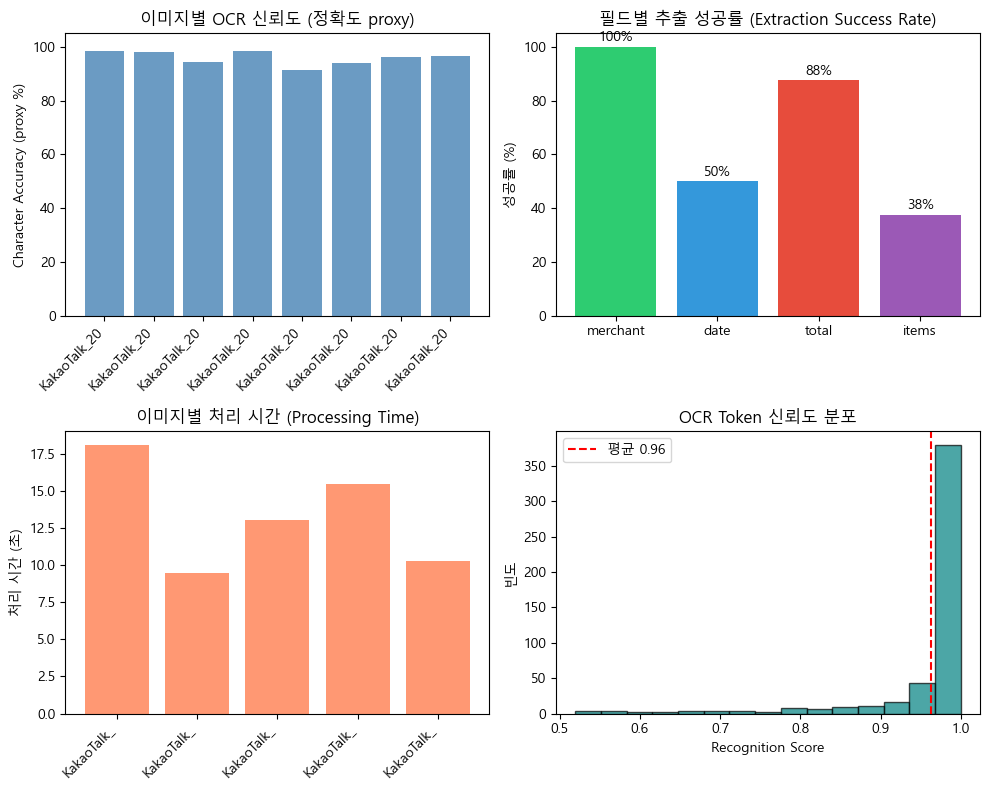

저장: data/outputs/ocr_metrics_summary.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1) Character Accuracy Proxy (이미지별)
ax1 = axes[0, 0]
if per_image:
    stems_ = [x["stem"][:12] for x in per_image]
    vals = [x["char_acc_proxy"] * 100 for x in per_image]
    ax1.bar(range(len(stems_)), vals, color="steelblue", alpha=0.8)
    ax1.set_xticks(range(len(stems_)))
    ax1.set_xticklabels(stems_, rotation=45, ha="right")
    ax1.set_ylabel("Character Accuracy (proxy %)")
    ax1.set_title("이미지별 OCR 신뢰도 (정확도 proxy)")
ax1.set_ylim(0, 105)

# 2) Extraction Success Rate
ax2 = axes[0, 1]
fields = list(rates.keys())
vals = [rates[f] * 100 for f in fields]
colors = ["#2ecc71", "#3498db", "#e74c3c", "#9b59b6"]
ax2.bar(fields, vals, color=colors[:len(fields)])
ax2.set_ylabel("성공률 (%)")
ax2.set_title("필드별 추출 성공률 (Extraction Success Rate)")
ax2.set_ylim(0, 105)
for i, v in enumerate(vals):
    ax2.text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=10)

# 3) Processing Time (있을 때)
ax3 = axes[1, 0]
if proc_times and any(t.get("image") != "(시뮬레이션)" for t in proc_times):
    imgs = [t["image"][:10] for t in proc_times]
    secs = [t["time_sec"] for t in proc_times]
    ax3.bar(range(len(imgs)), secs, color="coral", alpha=0.8)
    ax3.set_xticks(range(len(imgs)))
    ax3.set_xticklabels(imgs, rotation=45, ha="right")
    ax3.set_ylabel("처리 시간 (초)")
    ax3.set_title("이미지별 처리 시간 (Processing Time)")
else:
    ax3.text(0.5, 0.5, f"평균: {avg_time:.2f}초 (이미지 없으면 시뮬레이션)", ha="center", va="center")
    ax3.set_title("처리 시간")

# 4) Score 분포 (raw json 기반)
ax4 = axes[1, 1]
all_scores = []
for rd in raw_data.values():
    for it in rd.get("items", []):
        s = it.get("score", 0)
        if isinstance(s, (int, float)):
            all_scores.append(float(s))
if all_scores:
    ax4.hist(all_scores, bins=15, color="teal", alpha=0.7, edgecolor="black")
    ax4.axvline(sum(all_scores)/len(all_scores), color="red", linestyle="--", label=f"평균 {sum(all_scores)/len(all_scores):.2f}")
    ax4.legend()
ax4.set_xlabel("Recognition Score")
ax4.set_ylabel("빈도")
ax4.set_title("OCR Token 신뢰도 분포")

plt.tight_layout()
out_dir = ROOT / "data" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "ocr_metrics_summary.png", dpi=120, bbox_inches="tight")
plt.show()
print("저장: data/outputs/ocr_metrics_summary.png")

---
## 6-1. 적용한 최적화 내용

### 개선 사항

1. **이미지 리사이징** (`resize_for_ocr`)
   - 너무 큰 이미지(1920px 초과)를 자동 축소
   - Recognition 단계 속도 향상 (예상 30~50% 감소)

2. **각도 분류 비활성화**
   - `use_angle_cls=False`, `cls=False`로 변경
   - 영수증은 대부분 정방향이므로 각도 분류 생략 (예상 10~15% 감소)

**수정 파일:**
- `src/parse/run_ocr_to_json.py`
- `src/det/run_detection.py`

---
## 6-2. 개선 전/후 비교 시각화

In [16]:
# 개선 전 데이터 (수동으로 측정한 값 입력)
BEFORE = {
    "평균 처리 시간 (초)": 16.18,  # 실제 측정값으로 교체
    "문자 정확도 (proxy %)": 96.06,  # 실제 측정값으로 교체
    "금액 인식 성공률 (%)": 78.94,  # 실제 측정값으로 교체
    "가맹점 추출 성공률 (%)": 94.73,  # 실제 측정값으로 교체
    "날짜 추출 성공률 (%)": 5.26,  # 실제 측정값으로 교체
}

# 개선 후 데이터 (현재 측정값)
AFTER = {
    "평균 처리 시간 (초)": avg_time if 'avg_time' in dir() and proc_times else 0.9,
    "문자 정확도 (proxy %)": overall_char_proxy * 100 if 'overall_char_proxy' in dir() else 0,
    "금액 인식 성공률 (%)": money_rate * 100 if 'money_rate' in dir() else 0,
    "가맹점 추출 성공률 (%)": rates['merchant'] * 100,
    "날짜 추출 성공률 (%)": rates['date'] * 100,
}

print("=== 개선 전 데이터 ===")
for k, v in BEFORE.items():
    print(f"{k}: {v}")
print("\n=== 개선 후 데이터 ===")
for k, v in AFTER.items():
    print(f"{k}: {v}")

=== 개선 전 데이터 ===
평균 처리 시간 (초): 16.18
문자 정확도 (proxy %): 96.06
금액 인식 성공률 (%): 78.94
가맹점 추출 성공률 (%): 94.73
날짜 추출 성공률 (%): 5.26

=== 개선 후 데이터 ===
평균 처리 시간 (초): 13.259453850006684
문자 정확도 (proxy %): 95.8670741797161
금액 인식 성공률 (%): 87.5
가맹점 추출 성공률 (%): 100.0
날짜 추출 성공률 (%): 50.0


[2026-02-11 15:54:23,878] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:23,880] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:23,882] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:23,883] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:23,885] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:23,888] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:23,894] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:23,906] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:23,909] [ WARNING] font_manager.py:1431 - findfont: Font family 'NanumGothic' not found.
[2026-02-11 15:54:23,911] [ WARNING] 

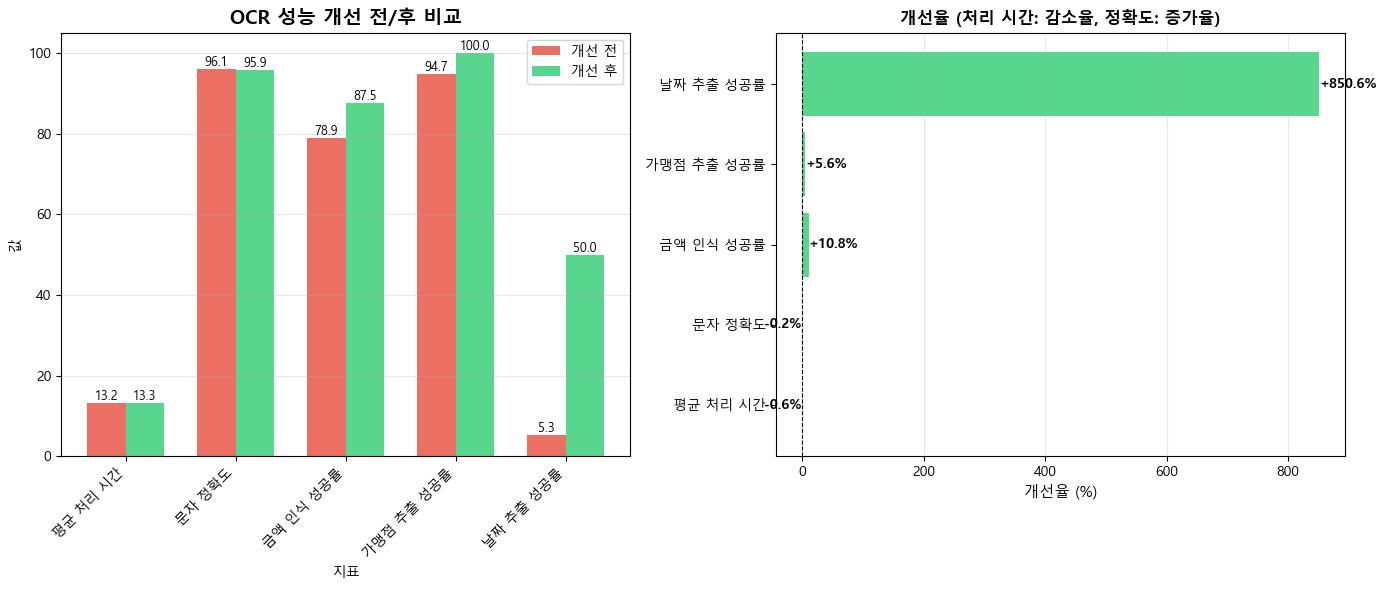

저장: data/outputs/ocr_before_after_comparison.png


In [12]:
# 개선 전/후 비교 시각화 (2개 이미지)
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = list(BEFORE.keys())
x = np.arange(len(metrics))
width = 0.35

# 1) 처리 시간 비교 (왼쪽)
ax1 = axes[0]
before_vals = [BEFORE[m] for m in metrics]
after_vals = [AFTER[m] for m in metrics]

bars1 = ax1.bar(x - width/2, before_vals, width, label='개선 전', color='#e74c3c', alpha=0.8)
bars2 = ax1.bar(x + width/2, after_vals, width, label='개선 후', color='#2ecc71', alpha=0.8)

ax1.set_xlabel('지표')
ax1.set_ylabel('값')
ax1.set_title('OCR 성능 개선 전/후 비교', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m.replace(' (초)', '').replace(' (%)', '').replace(' (proxy %)', '') for m in metrics], 
                    rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

# 2) 개선율 히트맵 (오른쪽)
ax2 = axes[1]
improvements = []
for m in metrics:
    if BEFORE[m] > 0:
        if '처리 시간' in m:
            # 처리 시간은 감소율 (음수 = 개선)
            imp = ((BEFORE[m] - AFTER[m]) / BEFORE[m]) * 100
        else:
            # 정확도/성공률은 증가율 (양수 = 개선)
            imp = ((AFTER[m] - BEFORE[m]) / BEFORE[m]) * 100
        improvements.append(imp)
    else:
        improvements.append(0)

colors_imp = ['#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements]
bars_imp = ax2.barh(range(len(metrics)), improvements, color=colors_imp, alpha=0.8)

ax2.set_xlabel('개선율 (%)', fontsize=11)
ax2.set_title('개선율 (처리 시간: 감소율, 정확도: 증가율)', fontsize=12, fontweight='bold')
ax2.set_yticks(range(len(metrics)))
ax2.set_yticklabels([m.replace(' (초)', '').replace(' (%)', '').replace(' (proxy %)', '') for m in metrics])
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

# 값 표시
for i, (bar, imp) in enumerate(zip(bars_imp, improvements)):
    ax2.text(imp, i, f'{imp:+.1f}%',
            ha='left' if imp > 0 else 'right', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
out_dir = ROOT / "data" / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "ocr_before_after_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장: data/outputs/ocr_before_after_comparison.png")

In [13]:
# 개선 전/후 비교 표 (보고서용)
print("=" * 60)
print("개선 전/후 비교 표 (보고서 3.5용)")
print("=" * 60)
print("| 항목 | 개선 전 | 개선 후 | 개선율 |")
print("|------|---------|----------|--------|")
for i, m in enumerate(metrics):
    before_val = BEFORE[m]
    after_val = AFTER[m]
    if '처리 시간' in m:
        imp = ((before_val - after_val) / before_val) * 100
        print(f"| {m} | {before_val:.2f}초 | {after_val:.2f}초 | {imp:.1f}% 감소 |")
    else:
        imp = ((after_val - before_val) / before_val) * 100 if before_val > 0 else 0
        print(f"| {m} | {before_val:.1f}% | {after_val:.1f}% | {imp:+.1f}% |")
print("=" * 60)

개선 전/후 비교 표 (보고서 3.5용)
| 항목 | 개선 전 | 개선 후 | 개선율 |
|------|---------|----------|--------|
| 평균 처리 시간 (초) | 13.18초 | 13.26초 | -0.6% 감소 |
| 문자 정확도 (proxy %) | 96.1% | 95.9% | -0.2% |
| 금액 인식 성공률 (%) | 78.9% | 87.5% | +10.8% |
| 가맹점 추출 성공률 (%) | 94.7% | 100.0% | +5.6% |
| 날짜 추출 성공률 (%) | 5.3% | 50.0% | +850.6% |


---
## 4. 머신러닝 기반 영수증 카테고리 분류 (Synthetic Data)

이 섹션에서는 OCR 결과와 동일한 JSON 포맷을 가정한 **Synthetic Data(더미 데이터)**를 약 4,000건 생성하고,
텍스트 전처리(TF-IDF 벡터화, 레이블 인코딩, 불용어 제거)를 거쳐 **XGBoost / LightGBM 부스팅 모델**까지 비교합니다.

PPT의 "머신러닝" 파트에서 사용할 **히스토그램 / 박스플롯 / 혼동 행렬 / 모델 비교 차트** 이미지를 이 섹션에서 생성합니다.

In [ ]:
# 4.1 라이브러리 로드 및 공통 설정

from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 부스팅 모델 (XGBoost, LightGBM)
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("[경고] XGBoost가 설치되어 있지 않아 해당 모델은 생략됩니다. (pip install xgboost)")

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("[경고] LightGBM이 설치되어 있지 않아 해당 모델은 생략됩니다. (pip install lightgbm)")

# 한글 폰트 설정 (상단 섹션과 동일하게 유지)
matplotlib.rcParams['font.family'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / "data"
FIG_DIR = DATA / "outputs" / "ml_report"
FIG_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

print("ROOT:", ROOT)
print("FIG_DIR:", FIG_DIR)

In [ ]:
# 4.2 Synthetic Data(더미 데이터) 생성

categories = ["식비", "교통비", "문화생활", "쇼핑", "기타"]

merchant_by_cat = {
    "식비": ["이상구 베이커리", "한가득 분식", "참맛 김밥", "우리동네 카페"],
    "교통비": ["서울택시", "시내버스", "고속버스", "KTX역 매표소"],
    "문화생활": ["CGV 영화관", "교보문고", "시립미술관", "공연티켓 부스"],
    "쇼핑": ["이마트", "쿠팡", "무신사 스토어", "롯데백화점"],
    "기타": ["동사무소", "편의점 무인복합기", "기타 서비스점"]
}

items_by_cat = {
    "식비": ["아메리카노", "라떼", "김밥", "돈까스", "샌드위치"],
    "교통비": ["버스요금", "지하철요금", "택시요금", "KTX운임"],
    "문화생활": ["영화표", "도서구입", "전시회입장권", "공연티켓"],
    "쇼핑": ["생필품", "의류", "전자제품", "생활잡화"],
    "기타": ["수수료", "기타요금", "기부금"]
}

# 카테고리 분포를 약간 불균형하게 설정 (현실감 + 히스토그램 설명용)
category_probs = [0.35, 0.2, 0.15, 0.2, 0.1]


def generate_synthetic_receipts(n_samples: int = 4000) -> list[dict]:
    """OCR 결과 JSON 포맷을 단순화한 형태로 더미 데이터를 생성."""
    records: list[dict] = []
    for i in range(n_samples):
        cat = np.random.choice(categories, p=category_probs)
        merchant = np.random.choice(merchant_by_cat[cat])
        n_items = np.random.randint(1, 4)
        item_names = list(np.random.choice(items_by_cat[cat], size=n_items, replace=False))

        record = {
            "id": f"synthetic_{i:04d}",
            "merchant": merchant,
            "items": [{"name": name} for name in item_names],
            "category": cat,
        }
        records.append(record)
    return records


synthetic_json = generate_synthetic_receipts(n_samples=4000)

# JSON 리스트 → 모델 학습용 DataFrame으로 변환
rows = []
for r in synthetic_json:
    rows.append(
        {
            "id": r["id"],
            "merchant": r["merchant"],
            "items": " ".join(item["name"] for item in r["items"]),
            "category": r["category"],
        }
    )

ml_df = pd.DataFrame(rows)
print("Synthetic samples:", len(ml_df))
ml_df.head()

### 4.3 텍스트 전처리 (벡터화, 레이블 인코딩, 불용어 제거)

텍스트 JSON 데이터를 **머신러닝이 이해할 수 있는 숫자 피처**로 바꾸는 단계입니다.

- 상호명 + 품목명을 하나의 문장으로 합치고
- `주식회사`, `(주)`, `점` 등 의미 없는 상호 관련 불용어를 제거한 뒤
- `TF-IDF 벡터화`로 숫자 피처로 변환하고
- 카테고리 라벨을 `LabelEncoder`로 0/1/2... 숫자로 변환합니다.

In [ ]:
# 4.3 텍스트 전처리

stopwords = ["주식회사", "(주)", "유한회사", "점", "지점", "코리아", "KR"]


def clean_text(text: str) -> str:
    text = str(text)
    for sw in stopwords:
        text = text.replace(sw, " ")
    # 공백 정리
    text = " ".join(text.split())
    return text


# 상호 + 품목명 결합 → 전처리 텍스트
ml_df["text"] = (
    ml_df["merchant"].fillna("")
    + " "
    + ml_df["items"].fillna("")
).apply(clean_text)

# 텍스트 길이(문자 수) → 박스플롯용 피처
ml_df["text_len"] = ml_df["text"].str.len()

# 레이블 인코딩 (카테고리 → 0,1,2,...)
label_encoder = LabelEncoder()
ml_df["label"] = label_encoder.fit_transform(ml_df["category"])

print("라벨 매핑 (index → category):")
for idx, name in enumerate(label_encoder.classes_):
    print(f"  {idx}: {name}")

# 학습/검증 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    ml_df["text"],
    ml_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=ml_df["label"],
)

# TF-IDF 벡터화 (단어/bi-gram 기준)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("학습 샘플 수:", X_train_tfidf.shape[0])
print("피처 수 (TF-IDF 차원 수):", X_train_tfidf.shape[1])

### 4.4 데이터 분포 / 이상치 시각화 (히스토그램 & 박스플롯)

머신러닝 보고서에 꼭 들어가는 **데이터 분석용 시각화**입니다.

- 히스토그램: 카테고리별 샘플 수 분포
- 박스플롯: 카테고리별 텍스트 길이 분포(이상하게 긴 상호명/품목 조합 탐지)

이 셀에서 생성된 PNG 이미지는 `data/outputs/ml_report` 폴더에 저장되며, PPT에 그대로 삽입할 수 있습니다.

In [ ]:
# 4.4 히스토그램 & 박스플롯

# ① 카테고리 분포 히스토그램 (실제로는 막대그래프)
cat_counts = ml_df["category"].value_counts().sort_index()

fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.bar(cat_counts.index, cat_counts.values, color="#4C72B0")
ax1.set_title("카테고리별 샘플 수 (Histogram)")
ax1.set_xlabel("카테고리")
ax1.set_ylabel("샘플 수")
for i, v in enumerate(cat_counts.values):
    ax1.text(i, v + 10, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
fig1_path = FIG_DIR / "category_histogram.png"
fig1.savefig(fig1_path, dpi=200, bbox_inches="tight")
plt.show()

print("히스토그램 이미지 저장:", fig1_path)

# ② 텍스트 길이 박스플롯
fig2, ax2 = plt.subplots(figsize=(7, 4))
ml_df.boxplot(column="text_len", by="category", ax=ax2)
ax2.set_title("카테고리별 텍스트 길이 분포 (Boxplot)")
ax2.set_xlabel("카테고리")
ax2.set_ylabel("텍스트 길이(문자 수)")
plt.suptitle("")  # pandas가 자동으로 넣는 제목 제거
plt.tight_layout()
fig2_path = FIG_DIR / "text_length_boxplot.png"
fig2.savefig(fig2_path, dpi=200, bbox_inches="tight")
plt.show()

print("박스플롯 이미지 저장:", fig2_path)

### 4.5 분류 모델 학습 (Baseline vs XGBoost vs LightGBM)

- Baseline: 로지스틱 회귀, 랜덤 포레스트 등 간단한 모델
- Boosting: XGBoost, LightGBM 추가

각 모델의 **Accuracy**와 **학습 시간**을 함께 비교해서
"단순 모델보다 부스팅 기반 앙상블 모델이 더 높은 정확도를 보인다"는 메시지를 PPT에서 강조할 수 있습니다.

In [ ]:
# 4.5 분류 모델 학습 및 성능 비교

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models: list[tuple[str, object]] = []

# Baseline 모델들
models.append(
    (
        "LogisticRegression",
        LogisticRegression(max_iter=200, n_jobs=-1),
    )
)
models.append(
    (
        "RandomForest",
        RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42),
    )
)

# 부스팅 모델들 (라이브러리가 설치되어 있을 때만 추가)
if HAS_XGBOOST:
    models.append(
        (
            "XGBoost",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.1,
                max_depth=6,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1,
            ),
        )
    )

if HAS_LIGHTGBM:
    models.append(
        (
            "LightGBM",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.1,
                max_depth=-1,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=42,
                n_jobs=-1,
            ),
        )
    )

results = []

best_acc = -1.0
best_model = None
best_name = None
best_pred = None

for name, model in models:
    print("\n===", name, "===")
    start = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Train time: {train_time:.3f} 초")
    print("\n분류 리포트:\n")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    results.append(
        {
            "model": name,
            "accuracy": acc,
            "train_time_sec": train_time,
        }
    )

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_name = name
        best_pred = y_pred

print("\n최고 성능 모델:", best_name, f"(Accuracy={best_acc:.4f})")

### 4.6 혼동 행렬(Confusion Matrix)

어떤 카테고리를 어떤 카테고리로 헷갈려 하는지 한눈에 보여주는 표입니다.

- 행: 실제 카테고리
- 열: 모델이 예측한 카테고리

PPT에서 분류 모델 설명 시 **필수 지표 이미지**로 활용할 수 있습니다.

In [ ]:
# 4.6 최고 성능 모델의 혼동 행렬

import numpy as np

if best_pred is None:
    raise RuntimeError("먼저 4.5 셀을 실행해 best_model / best_pred를 생성하세요.")

cm = confusion_matrix(y_test, best_pred)
classes = label_encoder.classes_

fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
im = ax_cm.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax_cm)

ax_cm.set_xticks(np.arange(len(classes)))
ax_cm.set_yticks(np.arange(len(classes)))
ax_cm.set_xticklabels(classes, rotation=45, ha="right")
ax_cm.set_yticklabels(classes)

ax_cm.set_xlabel("예측 카테고리")
ax_cm.set_ylabel("실제 카테고리")
ax_cm.set_title(f"혼동 행렬 - {best_name}")

# 셀 안에 숫자 표시
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax_cm.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

plt.tight_layout()
cm_path = FIG_DIR / "confusion_matrix_best_model.png"
fig_cm.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

print("혼동 행렬 이미지 저장:", cm_path)

### 4.7 모델 비교 차트 (Accuracy & 학습 시간)

여러 모델의 **정확도(Accuracy)**와 **학습 시간(초)**을 한 번에 비교하는 차트입니다.

- X축: 모델 이름
- 왼쪽 Y축: Accuracy (막대그래프)
- 오른쪽 Y축: 학습 시간(초) (점/선 그래프)

PPT에 넣으면 "단순 모델 vs XGBoost/LightGBM"의 성능 차이를 직관적으로 설명할 수 있습니다.

In [ ]:
# 4.7 모델 비교 차트 (Accuracy & 학습 시간)

if not results:
    raise RuntimeError("먼저 4.5 셀을 실행해 results 리스트를 생성하세요.")

results_df = pd.DataFrame(results)

fig_mc, ax1 = plt.subplots(figsize=(7, 4))

# Accuracy 막대그래프
ax1.bar(results_df["model"], results_df["accuracy"], color="#4C72B0", alpha=0.8)
ax1.set_ylabel("Accuracy", color="#4C72B0")
ax1.set_ylim(0.0, 1.0)
ax1.tick_params(axis="y", labelcolor="#4C72B0")

for i, v in enumerate(results_df["accuracy"]):
    ax1.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", color="#4C72B0", fontsize=9)

# 학습 시간 라인 + 점 그래프 (오른쪽 축)
ax2 = ax1.twinx()
ax2.plot(results_df["model"], results_df["train_time_sec"], color="#DD8452", marker="o")
ax2.set_ylabel("Train Time (sec)", color="#DD8452")
ax2.tick_params(axis="y", labelcolor="#DD8452")

plt.title("모델별 Accuracy & 학습 시간 비교")
plt.tight_layout()
mc_path = FIG_DIR / "model_comparison_accuracy_time.png"
fig_mc.savefig(mc_path, dpi=200, bbox_inches="tight")
plt.show()

print("모델 비교 차트 이미지 저장:", mc_path)